# Movie Review Sentiment Analysis

**Goal:** Predict whether a movie review is **positive** or **negative** from its text.

**Dataset:** IMDB Movie Reviews — 50,000 labelled reviews (balanced 50/50).
**Input (X):** the review text • **Target (y):** the sentiment

**Approach:** clean the text -> convert it to numbers with **TF-IDF** -> classify with **Logistic Regression** -> evaluate and interpret the results.

## Setup
Import the libraries we'll use.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42   # fixing the "seed" so we get the SAME results every run


## 1. Load the data

In [2]:
df = pd.read_csv("data/IMDB Dataset.csv")
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head()


Rows: 50,000   Columns: 2


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 2. Explore the data

**Class balance** — are positive/negative roughly equal?

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


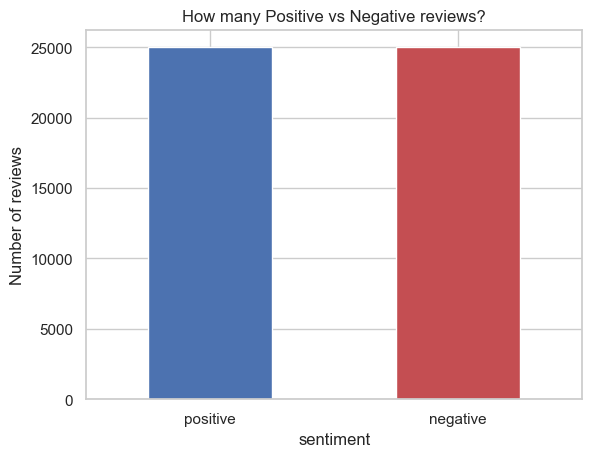

In [3]:
counts = df["sentiment"].value_counts()
print(counts)

counts.plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.title("How many Positive vs Negative reviews?")
plt.ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.show()


**Peek at a real review of each type:**

In [4]:
for label in ["positive", "negative"]:
    example = df[df.sentiment == label]["review"].iloc[0]
    print(f"\n===== A {label.upper()} review =====")
    print(example[:500], "...")



===== A POSITIVE review =====
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ ...

===== A NEGATIVE review =====
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in re

**Remove duplicate rows** (data hygiene):

In [5]:
print("Duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Rows after removing duplicates:", f"{len(df):,}")


Duplicate rows found: 418


Rows after removing duplicates: 49,582


## 3. Clean the text
Remove HTML tags and extra whitespace; keep the words.

In [6]:
def clean_text(text):
    text = re.sub(r"<.*?>", " ", text)   # remove HTML tags such as <br />
    text = re.sub(r"\s+", " ", text)     # squeeze repeated spaces into one
    return text.strip()

df["clean_review"] = df["review"].apply(clean_text)

# See the difference on one example:
print("BEFORE:\n", df["review"].iloc[0][:300])
print("\nAFTER:\n", df["clean_review"].iloc[0][:300])


BEFORE:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

AFTER:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this


## 4. Encode the labels
`positive -> 1`, `negative -> 0`.

In [7]:
# Models need numbers, not words. positive -> 1, negative -> 0
df["label"] = (df["sentiment"] == "positive").astype(int)
df[["sentiment", "label"]].head()


,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


## 5. Train / test split
Hold out 20% as an unseen test set so we measure *generalisation*, not memorisation.

In [8]:
X = df["clean_review"]   # the input  (what the model reads)
y = df["label"]          # the answer (what we want it to predict)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,            # keep 20% hidden for the final "exam"
    random_state=RANDOM_STATE,
    stratify=y,               # keep the 50/50 balance in both halves
)

print(f"Training reviews: {len(X_train):,}")
print(f"Testing reviews:  {len(X_test):,}")


Training reviews: 39,665
Testing reviews:  9,917


## 6. Convert text to numbers (TF-IDF)
TF-IDF scores each word by how distinctive it is. We include single words and two-word phrases, drop English stop-words, and fit the vocabulary on the **training set only**.

In [9]:
vectorizer = TfidfVectorizer(
    stop_words="english",   # ignore filler words like "the", "and", "of"
    ngram_range=(1, 2),     # learn single words AND two-word phrases ("not good")
    min_df=5,               # ignore rare words seen in fewer than 5 reviews
    max_features=20000,     # keep only the 20,000 most useful words/phrases
)

# IMPORTANT: fit the vocabulary on TRAIN only, then apply it to both sets.
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print("Training matrix shape:", X_train_vec.shape)
print(f"=> {X_train_vec.shape[0]:,} reviews, each described by "
      f"{X_train_vec.shape[1]:,} word-features.")


Training matrix shape: (39665, 20000)
=> 39,665 reviews, each described by 20,000 word-features.


## 7. Train the model
Logistic Regression learns a weight for every word-feature.

In [10]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)
print("Model trained!")


Model trained!


## 8. Evaluate on the test set

In [11]:
y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on reviews it has NEVER seen: {accuracy:.1%}\n")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))


Accuracy on reviews it has NEVER seen: 89.7%

              precision    recall  f1-score   support

    negative       0.91      0.88      0.89      4940
    positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



**Confusion matrix** — where the mistakes happen:

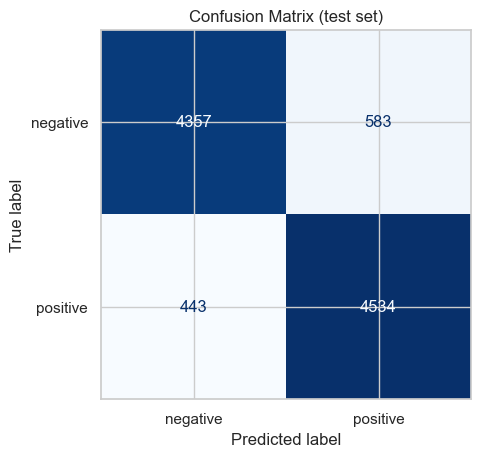

In [12]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["negative", "positive"]).plot(
    cmap="Blues", colorbar=False
)
plt.title("Confusion Matrix (test set)")
plt.show()


## 9. Interpret the model
Because the model is linear, its learned weights tell us which words signal each class.

In [13]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = model.coef_[0]   # one weight per word-feature

top_pos = np.argsort(coefs)[-15:][::-1]   # biggest positive weights
top_neg = np.argsort(coefs)[:15]          # biggest negative weights

print("Words/phrases that push a review toward POSITIVE:")
for i in top_pos:
    print(f"   +{coefs[i]:.2f}   {feature_names[i]}")

print("\nWords/phrases that push a review toward NEGATIVE:")
for i in top_neg:
    print(f"   {coefs[i]:.2f}   {feature_names[i]}")


Words/phrases that push a review toward POSITIVE:
   +7.69   great
   +6.95   excellent
   +5.77   best
   +5.51   perfect
   +5.26   amazing
   +5.24   wonderful
   +4.66   favorite
   +4.57   loved
   +4.51   brilliant
   +4.28   today
   +4.25   fun
   +4.16   enjoyed
   +4.09   hilarious
   +4.05   love
   +3.97   superb

Words/phrases that push a review toward NEGATIVE:
   -9.95   worst
   -8.03   awful
   -7.91   bad
   -7.00   boring
   -6.69   waste
   -6.26   poor
   -5.97   terrible
   -5.29   worse
   -5.21   horrible
   -5.17   dull
   -4.96   poorly
   -4.76   fails
   -4.65   disappointment
   -4.52   annoying
   -4.47   instead


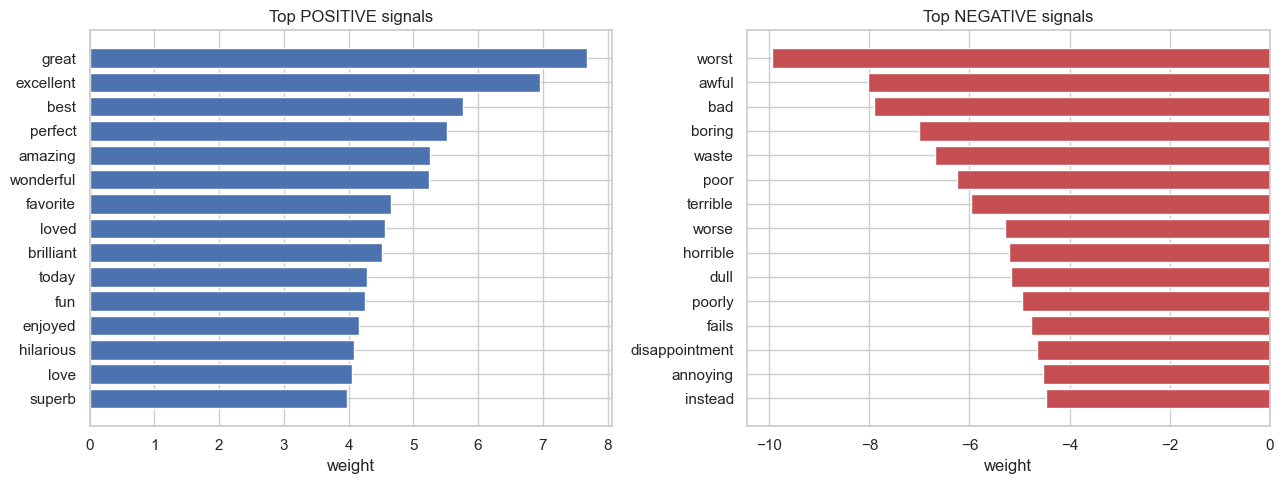

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(feature_names[top_pos][::-1], coefs[top_pos][::-1], color="#4C72B0")
axes[0].set_title("Top POSITIVE signals")
axes[0].set_xlabel("weight")

axes[1].barh(feature_names[top_neg][::-1], coefs[top_neg][::-1], color="#C44E52")
axes[1].set_title("Top NEGATIVE signals")
axes[1].set_xlabel("weight")

plt.tight_layout()
plt.show()


## 10. Try it on new reviews
A small helper that runs the full pipeline (clean -> vectorize -> predict) on any text.

In [15]:
def predict_sentiment(review):
    cleaned = clean_text(review)
    vec = vectorizer.transform([cleaned])
    prob_positive = model.predict_proba(vec)[0][1]
    verdict = "POSITIVE" if prob_positive >= 0.5 else "NEGATIVE"
    confidence = max(prob_positive, 1 - prob_positive)
    print(f'Review: "{review}"')
    print(f"Prediction: {verdict}   (confidence: {confidence:.0%})\n")

predict_sentiment("This movie was an absolute masterpiece. I loved every minute!")
predict_sentiment("What a boring, predictable waste of time. I want my money back.")
predict_sentiment("It was dark and heavy, but in the best possible way -- stunning.")


Review: "This movie was an absolute masterpiece. I loved every minute!"
Prediction: POSITIVE   (confidence: 88%)

Review: "What a boring, predictable waste of time. I want my money back."
Prediction: NEGATIVE   (confidence: 100%)

Review: "It was dark and heavy, but in the best possible way -- stunning."
Prediction: POSITIVE   (confidence: 88%)



In [16]:
# Change the text below to ANY review and run this cell:
predict_sentiment("Type your own movie review here!")


Review: "Type your own movie review here!"
Prediction: POSITIVE   (confidence: 51%)



## Conclusion
We built a text classifier that predicts movie-review sentiment with strong accuracy on unseen data. The model is interpretable — its learned weights reveal which words signal positive vs. negative sentiment. Its main failure cases are sarcasm and context-dependent words (e.g. *dark*, *heavy*), which motivates more advanced, context-aware models as a next step.

**Possible improvements:** larger n-grams, alternative classifiers (Naive Bayes, linear SVM), or deep-learning models that account for word order.